# 02_svd_global_compression — CIFAR-10（`src` / corrected）

原本 `02_svd_global_compression.ipynb` と同じ実験手順です。
定型処理だけ `src/nn_compression/` から import しています。

- `.py`：層の分解、rank sweep、学習ループ、指標計算など再利用処理
- `.ipynb`：今回 conv1/2/3 を対象にする、rank 候補、knee ±1、グラフ、保存名

出力先は `02_svd_global_compression_using_src_corrected`。 これは全 rank 空間の global optimum 探索ではない。 各 Conv を単独 sweep し、膝点付近（knee ±1）に探索範囲を制限した **model-wide rank allocation** である。
実行結果の参照は原本または `full/02_svd_global_compression_before_src.ipynb` に残しています。

```text
各層の重みをSVD
↓
特異値の減衰を見る
↓
rankを落としたときの精度低下を見る
↓
圧縮率とのトレードオフを見る
↓
conv1 / conv2 / conv3 それぞれの採用rankを決定
↓
モデル全体を低ランク化
↓
Fine-tuning
↓
Accuracy / Parameters / MACs評価
```


In [1]:
# 標準ライブラリ
from __future__ import annotations

from copy import deepcopy
import copy
from pathlib import Path
import json
import platform
import sys

# OpenMP / MKL の衝突回避に KMP_DUPLICATE_LIB_OK は使わない。
# 専用環境（例: conda env pytorch-svd）で実行する。
print("import: numpy / pandas / matplotlib", flush=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 評価
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# PyTorch
print("import: torch", flush=True)
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.preprocessing import MinMaxScaler

# Jupyter の cwd が notebooks/ でも src を見つける
for _candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    _src = _candidate / "src"
    if (_src / "nn_compression").is_dir():
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break

# ============================================================
# 【.py側をimport】原本ではここに def / class を書いていた処理
# ============================================================
print("import: nn_compression", flush=True)
from nn_compression.utils import (
    find_project_root,
    get_experiment_dirs,
    get_named_module,
    set_seed,
)
from nn_compression.training import (
    evaluate,
    fit_with_early_stopping,
    non_shuffling_loader,
    train_one_epoch,
)
from nn_compression.selection import (
    extract_pareto_frontier,
    find_knee_point,
    get_first_point,
    line_equation,
)
from nn_compression.metrics import (
    accuracy_drop,
    agreement,
    benchmark_inference,
    collect_compression_metrics,
    take_inference_batch,
    count_parameters,
    estimate_cnn_macs,
    estimate_conv2d_macs,
    logits_rmse,
    parameters_reduction,
)
from nn_compression.compression import (
    factorize_conv2d_layer,
    factorize_named_layers,
    retained_energy,
    sweep_conv_svd_ranks,
)
from nn_compression.models import CIFAR10CNN
from nn_compression.datasets import shuffled_index_splits


import: numpy / pandas / matplotlib
import: torch
import: nn_compression


## 1. 再現性と実行デバイス

Fashion-MNIST実験と比較しやすくするため、seedは同じ `0` を使う。

ここはCNN / CIFAR-10固有ではないので完成形。


In [2]:
# 再現性のため乱数seedを固定する
SEED = 0
set_seed(SEED)

# CUDA → MPS → CPU の順で利用可能なデバイスを選ぶ
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"device: {device}")
print(f"PyTorch: {torch.__version__}")


device: cuda
PyTorch: 2.11.0+cu128


## 2. 保存先

Fashion-MNIST版と同じルールで保存する。

```text
data/
models/30_cifar10/01_cnn_cifar10_baseline/
results/30_cifar10/01_cnn_cifar10_baseline/
```

`Path(".")` へ直接保存せず、プロジェクトルート基準にする。


In [3]:
DATASET_NAME = "30_cifar10"
# 原本の results/models を上書きしない
EXPERIMENT_NAME = "02_svd_global_compression_using_src_corrected"

project_root = find_project_root(Path.cwd())
data_dir, models_dir, results_dir = get_experiment_dirs(
    project_root,
    DATASET_NAME,
    EXPERIMENT_NAME,
)

checkpoint_dir = models_dir
csv_dir = results_dir
figure_dir = results_dir
metadata_dir = results_dir

print("project_root:", project_root)
print("data_dir:", data_dir)
print("models_dir:", models_dir)
print("results_dir:", results_dir)


project_root: D:\dev\nn-compression-svd-dmrg
data_dir: D:\dev\nn-compression-svd-dmrg\data
models_dir: D:\dev\nn-compression-svd-dmrg\models\30_cifar10\02_svd_global_compression_using_src_corrected
results_dir: D:\dev\nn-compression-svd-dmrg\results\30_cifar10\02_svd_global_compression_using_src_corrected


## 3. CIFAR-10の前処理

CIFAR-10では、trainにだけ軽いaugmentationを入れる。

### 考えること

Fashion-MNISTでは `ToTensor()` だけだった。  
今回は次の処理が何をしているか確認する。

- `RandomCrop`
- `RandomHorizontalFlip`
- `Normalize`

### ヒント

`Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))` を通すと、  
`ToTensor()` 後の `[0, 1]` 付近の値域が、おおむね0を中心とする範囲へ移る。

trainとvalidationで**同じ元画像を使っていても、transformは分けたい**ことに注意。


In [4]:
import torchvision.transforms as transforms

# 学習データ専用の前処理（Data Augmentation を含む）
#transforms.Compose([...]) は、リスト中の変換を上から順番に連結して実行する仕組みです。
train_transform = transforms.Compose(
    [
        # 元画像（32 x 32）の周囲を4 pixelぶんゼロ埋めして40 x 40にして
        # 領域内からランダムな位置で 32 x 32 を切り出す。
        # 物体の位置が少しずれても認識できるように学習させる。
        transforms.RandomCrop(
            size=32,
            padding=4,
        ),

        # 確率 p=0.5（デフォルト）で画像を左右反転する。
        # CIFAR-10では、左右が反転しても通常はクラスが変わらないため有効。
        # 例: 左向きの車も右向きの車も automobile として学習する。
        transforms.RandomHorizontalFlip(),

        # PIL Image / NumPy配列をPyTorch Tensorに変換する。
        # 形状: (H, W, C) = (32, 32, 3) -> (C, H, W) = (3, 32, 32)
        # 型・値域: uint8 の [0, 255] -> float32 の [0.0, 1.0]
        transforms.ToTensor(),

        # RGB各チャネルを同じ平均・標準偏差で正規化する。
        # 各画素値 x (ToTensor後は [0, 1]) に対し、
        # x_normalized = (x - 0.5) / 0.5 を適用する。
        # その結果、値域は概ね [0, 1] -> [-1, 1] となる。
        transforms.Normalize(
            mean=(0.5, 0.5, 0.5),  # R, G, B の平均との差し引き用
            std=(0.5, 0.5, 0.5),   # R, G, B のスケール調整用
        ),
    ]
)


# 検証・テスト専用の前処理
evaluation_transform = transforms.Compose(
    [
        # 評価時もCNNに渡せるTensor形式へ変換する。
        # (32, 32, 3) -> (3, 32, 32)、[0, 255] -> [0.0, 1.0]
        transforms.ToTensor(),

        # 学習時と「まったく同じ」正規化を行う。
        # 学習と評価でスケールが違うと、入力分布が変わって正しい評価にならない。
        transforms.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
        ),
    ]
)

## 4. train / validation / test の作成

CIFAR-10公式データは

- train: 50,000
- test: 10,000

なので、train側を

- train: 45,000
- validation: 5,000

に分ける。

### Fashion-MNIST版との小さな違い

単純に1個のDatasetへ `random_split()` すると、分割後も元Datasetのtransformを共有する。

今回は

```text
train      → augmentationあり
validation → augmentationなし
```

にしたい。

そのため、**同じ50,000枚を別transformで読み込むDatasetを2個作り、同じindex分割を使う**。


In [5]:
# ============================================================
# CIFAR-10を最初の1回だけダウンロードする
# ============================================================

full_train_augmented = datasets.CIFAR10(
    root=data_dir,
    train=True,
    # 今回はミラーサイトから手動でDLしたためFalse
    download=False,
    transform=train_transform,
)

# すでにダウンロード済みなので download=False
full_train_evaluation = datasets.CIFAR10(
    root=data_dir,
    train=True,
    download=False,
    transform=evaluation_transform,
)

# testデータも同じCIFAR-10アーカイブ内に含まれている
test_dataset = datasets.CIFAR10(
    root=data_dir,
    train=False,
    download=False,
    transform=evaluation_transform,
)

TRAIN_SIZE = 40_000
VALIDATION_SIZE = 5_000

# ------------------------------------------------------------
# train / validation のindexを固定
# SEED が同じなら randperm 結果も同一になり、割当を再現できる。
# 【.py】datasets/splits.py。分割長だけ実験条件
# ------------------------------------------------------------
train_indices, validation_indices_early_stop, validation_indices_rank = (
    shuffled_index_splits(
        len(full_train_augmented),
        (TRAIN_SIZE, VALIDATION_SIZE, VALIDATION_SIZE),
        seed=SEED,
    )
)

# ------------------------------------------------------------
# 同じ元データだがtransformを変える
# ------------------------------------------------------------

# train: augmentationあり
train_dataset = Subset(
    dataset=full_train_augmented,
    indices=train_indices,
)

# validation: augmentationなし
validation_dataset_early_stop = Subset(
    dataset=full_train_evaluation,
    indices=validation_indices_early_stop,
)

validation_dataset_rank = Subset(
    dataset=full_train_evaluation,
    indices=validation_indices_rank,
)

print(f"train:      {len(train_dataset):,}")
print(f"validation: {len(validation_dataset_early_stop):,}")
print(f"validation: {len(validation_dataset_rank):,}")
print(f"test:       {len(test_dataset):,}")


train:      40,000
validation: 5,000
validation: 5,000
test:       10,000


## 5. DataLoader

CIFAR-10はFashion-MNISTより1画像あたりのデータ量が増えるので、まず `batch_size=128` から始める。

Windows + Notebookでトラブルを減らすため、最初は `num_workers=2`。

動作確認後に `2`, `4`, `8` などを実測してよい。


In [6]:
BATCH_SIZE = 256
NUM_WORKERS = 0
# shuffleの順序も再現しやすくする
loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    generator=loader_generator,
)
train_eval_loader = non_shuffling_loader(train_loader)

validation_loader_early_stop = DataLoader(
    validation_dataset_early_stop,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

validation_loader_rank = DataLoader(
    validation_dataset_rank,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

# train_loaderをnext(iter(...))するとshuffle用Generatorを消費するので、
# shape確認だけならDatasetから1件直接取り出す
image, label = train_dataset[0]

print(f"image shape: {tuple(image.shape)}")
print(f"label: {label}")
print(
    "expected batch shape: "
    f"({BATCH_SIZE}, {image.shape[0]}, {image.shape[1]}, {image.shape[2]})"
)


image shape: (3, 32, 32)
label: 6
expected batch shape: (256, 3, 32, 32)


## 7. CNNモデル

クラス本体は `src/nn_compression/models/cifar10.py`。
チャネル数・Dropout・クラス数は次のセルの実験条件を渡す。


In [7]:
# ============================================================
# TODO: ここだけ自分で埋める（実験条件。クラス本体は src）
# ============================================================
MODEL_CONFIG = {
    "input_channels": 3,
    "conv2_in_channels": 32,
    "conv3_in_channels": 64,
    "flatten_dim": 128,
    "num_classes": 10,  # 各クラスの分類スコア
}

# 固定する設計値
CONV1_OUT_CHANNELS = 32
CONV2_OUT_CHANNELS = 64
CONV3_OUT_CHANNELS = 128
HIDDEN_DIM = 256
DROPOUT_RATE = 0.5


def validate_model_config(config: dict[str, int | None]) -> None:
    """未入力の設定が残っていないか確認する。"""

    missing = [
        key
        for key, value in config.items()
        if value is None
    ]

    if missing:
        raise ValueError(
            "MODEL_CONFIG に未入力があります: "
            + ", ".join(missing)
        )


# 先へ進む前に、上のNoneを自分で埋める
validate_model_config(MODEL_CONFIG)


In [8]:
# モデル定義は src/nn_compression/models/cifar10.py。
# チャネル数・クラス数・Dropout は直前セルの実験条件を渡す。


def make_experiment_cnn() -> CIFAR10CNN:
    """今回の MODEL_CONFIG で CIFAR10CNN を組み立てる。"""
    return CIFAR10CNN(
        in_channels=MODEL_CONFIG["input_channels"],
        conv_channels=(
            CONV1_OUT_CHANNELS,
            CONV2_OUT_CHANNELS,
            CONV3_OUT_CHANNELS,
        ),
        hidden_dim=HIDDEN_DIM,
        num_classes=MODEL_CONFIG["num_classes"],
        dropout=DROPOUT_RATE,
    )


## 8. shape確認

学習前にdummy inputを通す。

期待する最終shapeは

```text
(batch_size, クラス数)
```

ここでは32枚の仮想batchを使う。

**実行前にoutput shapeを予想してから実行する。**


In [9]:
set_seed(SEED)
baseline_model = make_experiment_cnn().to(device)
baseline_model.eval()
print(baseline_model)

# CIFAR-10 32枚分のdummy input
dummy_input = torch.zeros(
    32,
    MODEL_CONFIG["input_channels"],
    32,
    32,
    device=device,
)

# shape確認だけなので勾配計算は不要
with torch.inference_mode():
    dummy_output = baseline_model(dummy_input)

print(f"input shape:  {tuple(dummy_input.shape)}")
print(f"output shape: {tuple(dummy_output.shape)}")

# 最終出力は「32枚 × クラス数」になるはず
assert tuple(dummy_output.shape) == (
    32,
    MODEL_CONFIG["num_classes"],
)
baseline_model.train()


CIFAR10CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=128, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
input shape:  (32, 3, 32, 32)
output shape: (32, 10)


CIFAR10CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=128, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

## 9. パラメータ数


In [10]:
baseline_parameter_count = count_parameters(
    baseline_model
)

print(f"total parameters: {baseline_parameter_count:,}")
print()

# 層ごとのparameter shapeと要素数を見る
for name, parameter in baseline_model.named_parameters():
    print(
        f"{name:20s} "
        f"shape={str(tuple(parameter.shape)):20s} "
        f"params={parameter.numel():,}"
    )


total parameters: 128,842

conv1.weight         shape=(32, 3, 3, 3)        params=864
conv1.bias           shape=(32,)                params=32
conv2.weight         shape=(64, 32, 3, 3)       params=18,432
conv2.bias           shape=(64,)                params=64
conv3.weight         shape=(128, 64, 3, 3)      params=73,728
conv3.bias           shape=(128,)               params=128
fc1.weight           shape=(256, 128)           params=32,768
fc1.bias             shape=(256,)               params=256
fc2.weight           shape=(10, 256)            params=2,560
fc2.bias             shape=(10,)                params=10


### SVDへ向けた確認


## 10. Baseline学習

定型部分なので完成形。

今回はまず

- loss: `CrossEntropyLoss`
- optimizer: `Adam`
- learning rate: `1e-3`
- 最大epoch: `20`

でbaselineを作る。

validation lossが最小だったepochの重みを残す。

testはモデル選択に使わず、最後に1回評価する。


`fit_with_early_stopping` は `src/nn_compression/training/fit.py`。

Fashion-MNIST と同じ既定は、毎 epoch に train 全件を再評価する。
この実験では `reevaluate_train=False`（学習中指標を履歴に使う）と
`log_every_epoch=True`（毎 epoch 進捗表示）を渡す。
学習率・epoch・patience はこれまでどおり Notebook の実験条件。


In [11]:
# 学習ループ本体は src/nn_compression/training/fit.py。
# Fashion-MNIST の既定（毎epochに train 全件を再評価、Early Stopping 時だけ print）
# は変えない。この実験だけキーワード専用引数で軽量化する。
#
#   reevaluate_train=False  ... 履歴の train 指標は train_one_epoch の戻り値
#   log_every_epoch=True    ... 毎 epoch 進捗を出す


In [12]:
# 多クラス分類なのでCrossEntropyLoss
# モデル側ではsoftmaxをかけず、生のlogitsを返す
criterion = nn.CrossEntropyLoss()

BASELINE_LEARNING_RATE = 1e-3
BASELINE_EPOCHS = 50
PATIENCE=3
MIN_DELTA = 1e-4

# このセルを再実行すると、前回の重みと消費済み乱数から続きになる。
# Dropout / RandomCrop / shuffle もグローバル乱数を使うので、
# 学習直前に seed・初期重み・DataLoader の shuffle を戻す。
set_seed(SEED)
baseline_model = make_experiment_cnn().to(device)
loader_generator.manual_seed(SEED)

optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=BASELINE_LEARNING_RATE,
)

# 【.py】training/fit.py。train 再評価は省略、毎epoch print
baseline_fit = fit_with_early_stopping(
    baseline_model,
    train_loader,
    validation_loader_early_stop,
    criterion,
    optimizer,
    device,
    BASELINE_EPOCHS,
    PATIENCE,
    MIN_DELTA,
    reevaluate_train=False,
    log_every_epoch=True,
)


epoch=01 train_loss=1.9898 train_acc=0.2391 val_loss=1.8510 val_acc=0.3178
epoch=02 train_loss=1.7382 train_acc=0.3371 val_loss=1.6422 val_acc=0.3820
epoch=03 train_loss=1.6264 train_acc=0.3867 val_loss=1.5159 val_acc=0.4336
epoch=04 train_loss=1.5390 train_acc=0.4252 val_loss=1.4482 val_acc=0.4624
epoch=05 train_loss=1.4609 train_acc=0.4583 val_loss=1.4228 val_acc=0.4796
epoch=06 train_loss=1.4056 train_acc=0.4815 val_loss=1.3375 val_acc=0.5054
epoch=07 train_loss=1.3462 train_acc=0.5048 val_loss=1.2653 val_acc=0.5370
epoch=08 train_loss=1.3001 train_acc=0.5256 val_loss=1.2513 val_acc=0.5380
epoch=09 train_loss=1.2558 train_acc=0.5434 val_loss=1.1969 val_acc=0.5648
epoch=10 train_loss=1.2118 train_acc=0.5589 val_loss=1.1663 val_acc=0.5760
epoch=11 train_loss=1.1893 train_acc=0.5687 val_loss=1.1497 val_acc=0.5820
epoch=12 train_loss=1.1352 train_acc=0.5916 val_loss=1.1319 val_acc=0.5884
epoch=13 train_loss=1.1152 train_acc=0.5987 val_loss=1.0902 val_acc=0.6134
epoch=14 train_loss=1.082

In [13]:
# fit_with_early_stopping の学習履歴。CSV保存とグラフ用に取り出す
history = baseline_fit["history"]
train_loss_history = baseline_fit["train_loss_history"]
validation_loss_history = baseline_fit["validation_loss_history"]
best_epoch = baseline_fit["best_epoch"]
best_validation_loss = baseline_fit["best_validation_loss"]
df_training_history = pd.DataFrame(history)

print()
print(f"best epoch: {best_epoch}")
print(
    "best validation loss: "
    f"{best_validation_loss:.4f}"
)
print(f"epochs recorded: {len(history)}")

# epochごとの詳細履歴（loss / acc）
history_csv = csv_dir / "fit_history.csv"
df_training_history.to_csv(history_csv, index=False)

# 戻り値の1次元リストも保存しておく
loss_history_csv = csv_dir / "fit_loss_history.csv"
pd.DataFrame(
    {
        "epoch": list(range(1, len(train_loss_history) + 1)),
        "train_loss": train_loss_history,
        "validation_loss": validation_loss_history,
    }
).to_csv(loss_history_csv, index=False)

print("saved:", history_csv)
print("saved:", loss_history_csv)



best epoch: 34
best validation loss: 0.7601
epochs recorded: 37
saved: D:\dev\nn-compression-svd-dmrg\results\30_cifar10\02_svd_global_compression_using_src_corrected\fit_history.csv
saved: D:\dev\nn-compression-svd-dmrg\results\30_cifar10\02_svd_global_compression_using_src_corrected\fit_loss_history.csv


Best epoch: 34
Best validation loss: 0.7601


,epoch,train_acc,train_loss,validation_loss,validation_acc
0,1,0.239075,1.989808,1.850958,0.3178
1,2,0.337050,1.738160,1.642216,0.3820
2,3,0.386675,1.626436,1.515880,0.4336
3,4,0.425175,1.539022,1.448238,0.4624
4,5,0.458350,1.460897,1.422790,0.4796
5,6,0.481525,1.405620,1.337484,0.5054
6,7,0.504750,1.346233,1.265279,0.5370
7,8,0.525650,1.300060,1.251335,0.5380
8,9,0.543450,1.255795,1.196933,0.5648
9,10,0.558925,1.211826,1.166273,0.5760


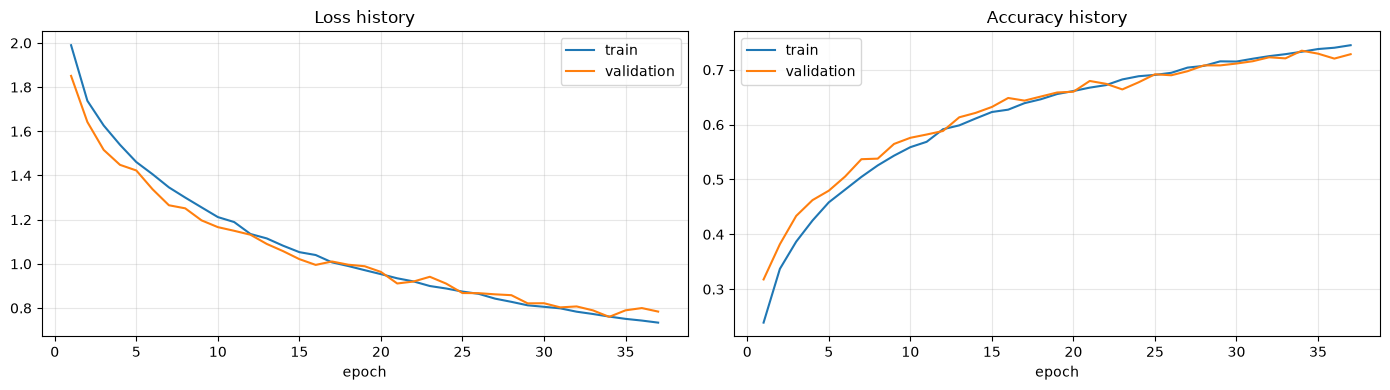

In [14]:
from IPython.display import display

model = baseline_fit["model"]
baseline_state = copy.deepcopy(model.state_dict())

# 【.ipynb側】履歴を DataFrame / グラフにするのは実験ノートの仕事
df_training_history = pd.DataFrame(baseline_fit["history"])

print("Best epoch:", baseline_fit["best_epoch"])
print(f"Best validation loss: {baseline_fit['best_validation_loss']:.4f}")
display(df_training_history)

fig_learning, axes_learning = plt.subplots(1, 2, figsize=(14, 4))
axes_learning[0].plot(df_training_history["epoch"], df_training_history["train_loss"], label="train")
axes_learning[0].plot(df_training_history["epoch"], df_training_history["validation_loss"], label="validation")
axes_learning[0].set_title("Loss history")
axes_learning[0].set_xlabel("epoch")
axes_learning[0].legend()
axes_learning[0].grid(True, alpha=0.3)

axes_learning[1].plot(df_training_history["epoch"], df_training_history["train_acc"], label="train")
axes_learning[1].plot(df_training_history["epoch"], df_training_history["validation_acc"], label="validation")
axes_learning[1].set_title("Accuracy history")
axes_learning[1].set_xlabel("epoch")
axes_learning[1].legend()
axes_learning[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. RankSweep（conv1 / conv2 / conv3）

各 Conv を **1層だけ** SVD して rank を振る。
MACs は `estimate_conv2d_macs`（層と出力 HW を渡す汎用関数）を使う。
`estimate_cnn_conv2_macs` は Fashion-MNIST 04 互換のラッパー。


In [15]:
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

# rank sweep 本体は src。ここは Pareto 図・CSV名・knee±1 という実験判断。


def select_pareto_knee(
    rank_results: list[dict],
    model: nn.Module,
    layer_name: str,
    results_dir: Path,
) -> dict:
    """1層の rank sweep から Pareto と knee±1 を選ぶ。

    【.py】Pareto 判定と knee 距離だけ src。
    【.ipynb】どの点を落とすか、どの列を正規化するか、ファイル名、
    knee の前後1点を候補にするかは実験判断。
    """
    baseline_params = count_parameters(model)
    df_rank_results = pd.DataFrame(rank_results)

    # パラメータが増える分解や、演算が減らない rank は候補から外す
    df_pareto_input = df_rank_results[
        (df_rank_results["parameters"] <= baseline_params)
        & (df_rank_results["compute_reduction"] > 0)
    ].copy()

    # 両軸とも小さいほど良い（params 少、val loss 低）非劣後点
    df_pareto_view = extract_pareto_frontier(
        df_pareto_input,
        x_column="parameters",
        y_column="validation_loss",
    )
    # 軸のスケールが違うと knee の「最も遠い点」が一方に偏るので 0-1 に揃える
    scaler = MinMaxScaler()
    df_pareto_view[
        ["parameters_normalize", "validation_loss_normalize"]
    ] = scaler.fit_transform(
        df_pareto_view[["parameters", "validation_loss"]]
    )

    fig_pareto, axes_pareto = plt.subplots(1, 2, figsize=(16, 4))
    axes_pareto[0].scatter(
        df_pareto_view["parameters"],
        df_pareto_view["validation_loss"],
    )
    axes_pareto[0].set_xlabel("parameters")
    axes_pareto[0].set_ylabel("validation_loss")
    axes_pareto[0].set_title(
        f"{layer_name}: parameters vs validation_loss"
    )
    axes_pareto[1].scatter(
        df_pareto_view["parameters_normalize"],
        df_pareto_view["validation_loss_normalize"],
    )
    axes_pareto[1].set_xlabel("parameters_normalize")
    axes_pareto[1].set_ylabel("validation_loss_normalize")
    axes_pareto[1].set_title(f"{layer_name}: normalized")
    plt.tight_layout()

    print(f"{layer_name} pareto points:", len(df_pareto_view))
    display(
        df_pareto_view[
            [
                "layer",
                "rank",
                "parameters",
                "validation_loss",
                "parameters_normalize",
                "validation_loss_normalize",
            ]
        ]
    )

    # 層ごとにファイルを分ける。model 列は PyTorch オブジェクトなので落とす
    results_dir.mkdir(parents=True, exist_ok=True)
    rank_sweep_path = results_dir / f"rank_sweep_results_{layer_name}.csv"
    pareto_path = results_dir / f"pareto_frontier_{layer_name}.csv"
    pareto_figure_path = (
        results_dir
        / f"parameters_vs_validation_loss_normalize_{layer_name}.png"
    )
    df_rank_results.drop(columns=["model"], errors="ignore").to_csv(
        rank_sweep_path,
        index=False,
    )
    df_pareto_view.drop(columns=["model"], errors="ignore").to_csv(
        pareto_path,
        index=False,
    )
    fig_pareto.savefig(pareto_figure_path, dpi=150, bbox_inches="tight")
    print("saved:", rank_sweep_path)
    print("saved:", pareto_path)
    print("saved:", pareto_figure_path)
    plt.show()

    # 正規化空間で「params最小」と「loss最小」を端点にする
    p0 = get_first_point(
        df_pareto_view,
        "parameters_normalize",
        "parameters_normalize",
        "validation_loss_normalize",
    )
    p1 = get_first_point(
        df_pareto_view,
        "validation_loss_normalize",
        "parameters_normalize",
        "validation_loss_normalize",
    )
    # 端点を結ぶ直線から最も遠い点が knee（曲がり角）
    knee_point, knee_distance = find_knee_point(
        df_pareto_view,
        *line_equation(p0, p1),
        "parameters_normalize",
        "validation_loss_normalize",
    )
    df_pareto_view = df_pareto_view.sort_values(
        "parameters"
    ).reset_index(drop=True)
    knee_mask = (
        (df_pareto_view["parameters_normalize"] == knee_point[0])
        & (df_pareto_view["validation_loss_normalize"] == knee_point[1])
    )
    knee_pos = int(df_pareto_view.index[knee_mask][0])
    # Fine-tuning 候補は knee とその前後1点
    left = max(knee_pos - 1, 0)
    right = min(knee_pos + 1, len(df_pareto_view) - 1)
    df_pareto_knee = df_pareto_view.iloc[[knee_pos]].copy()
    df_pareto_best = df_pareto_view.iloc[left : right + 1].copy()

    print("knee distance:", knee_distance)
    print(
        f"knee_pos={knee_pos}, neighbors iloc[{left}:{right + 1}]"
    )
    print("knee:")
    display(df_pareto_knee.drop(columns=["model"], errors="ignore"))
    print("knee ±1:")
    display(df_pareto_best.drop(columns=["model"], errors="ignore"))

    return {
        "df_rank_results": df_rank_results,
        "df_pareto_view": df_pareto_view,
        "df_pareto_knee": df_pareto_knee,
        "df_pareto_best": df_pareto_best,
        "knee_distance": knee_distance,
    }


In [16]:
# ============================================================
# 【.ipynb側】どの層を、どの空間サイズ・どの rank で振るか
# 【.py側】分解・evaluate・指標計算は sweep_conv_svd_ranks
# ============================================================

# Conv 出力の空間サイズ（pool 前）。
# kernel=3, padding=1, stride=1 なので入力と同じ。
# 32 → pool → 16 → pool → 8
CONV_OUTPUT_HW = {
    "conv1": (32, 32),
    "conv2": (16, 16),
    "conv3": (8, 8),
}

# 最大 rank は min(out_ch, in_ch * kH * kW)
# conv1: min(32, 3*3*3) = 27
# conv2: min(64, 32*3*3) = 64
# conv3: min(128, 64*3*3) = 128
# リストは実験判断。密に振るほど時間は増える
CONV_RANK_CANDIDATES = {
    "conv1": [3, 6, 9, 12, 15, 18, 21, 24, 27],
    "conv2": [8, 16, 24, 32, 40, 48, 56, 64],
    "conv3": [16, 32, 48, 64, 80, 96, 112, 128],
}

# 圧縮前モデルの基準値は3層で共用する。毎回測ると時間が3倍になる
# warmup は計測に入れない。repeats は Fashion-MNIST 04 に合わせている
BENCH_WARMUP = 20
BENCH_REPEATS = 2000
inference_batch = take_inference_batch(validation_loader_rank)
baseline_bench = benchmark_inference(
    model,
    device=device,
    warmup=BENCH_WARMUP,
    repeats=BENCH_REPEATS,
    input_batch=inference_batch,
    return_details=True,
)
baseline_time_s = baseline_bench["time_s"]
print(
    "benchmark batch_size",
    baseline_bench["batch_size"],
    "shape",
    baseline_bench["input_shape"],
)
# Early Stopping 用ではなく、rank 選択用の validation
baseline_rank_validation_loss, baseline_rank_validation_acc = evaluate(
    model,
    validation_loader_rank,
    criterion,
    device,
)
print(
    "baseline rank-val "
    f"acc={baseline_rank_validation_acc:.4f} "
    f"loss={baseline_rank_validation_loss:.4f}"
)

# 層ごとの結果表。後で Fine-tuning するとき layer_rank_results["conv1"] を見る
layer_rank_results: dict[str, list[dict]] = {}
for layer_name, rank_list in CONV_RANK_CANDIDATES.items():
    print(f"\n=== sweep {layer_name} ===")
    layer_rank_results[layer_name] = sweep_conv_svd_ranks(
        model,
        layer_name,
        rank_list,
        CONV_OUTPUT_HW[layer_name],
        validation_loader_rank,
        criterion,
        device,
        baseline_acc=baseline_rank_validation_acc,
        baseline_time_s=baseline_time_s,
        warmup=BENCH_WARMUP,
        repeats=BENCH_REPEATS,
        input_batch=inference_batch,
    )


benchmark batch_size 256 shape (256, 3, 32, 32)
baseline rank-val acc=0.7344 loss=0.7602

=== sweep conv1 ===
conv1 r=  3| Acc=0.2538 loss=2.9606 | params=128155 MACs=181248 | agreement=0.2688
conv1 r=  6| Acc=0.5110 loss=1.6353 | params=128332 MACs=362496 | agreement=0.5776
conv1 r=  9| Acc=0.5556 loss=1.4575 | params=128509 MACs=543744 | agreement=0.6318
conv1 r= 12| Acc=0.5942 loss=1.3045 | params=128686 MACs=724992 | agreement=0.6842
conv1 r= 15| Acc=0.6164 loss=1.2188 | params=128863 MACs=906240 | agreement=0.7196
conv1 r= 18| Acc=0.6986 loss=0.8663 | params=129040 MACs=1087488 | agreement=0.8554
conv1 r= 21| Acc=0.7100 loss=0.8445 | params=129217 MACs=1268736 | agreement=0.8762
conv1 r= 24| Acc=0.7248 loss=0.7854 | params=129394 MACs=1449984 | agreement=0.9426
conv1 r= 27| Acc=0.7344 loss=0.7602 | params=129571 MACs=1631232 | agreement=1.0000
集計完了: conv1 9 件

=== sweep conv2 ===
conv2 r=  8| Acc=0.3910 loss=1.7246 | params=113226 MACs=720896 | agreement=0.4416
conv2 r= 16| Acc=0.


=== pareto / knee conv1 ===
conv1 pareto points: 4


,layer,rank,parameters,validation_loss,parameters_normalize,validation_loss_normalize
0,conv1,3,128155,2.960636,0.000000,1.000000
1,conv1,6,128332,1.635332,0.333333,0.199754
2,conv1,9,128509,1.457474,0.666667,0.092360
3,conv1,12,128686,1.304514,1.000000,0.000000


saved: D:\dev\nn-compression-svd-dmrg\results\30_cifar10\02_svd_global_compression_using_src_corrected\rank_sweep_results_conv1.csv
saved: D:\dev\nn-compression-svd-dmrg\results\30_cifar10\02_svd_global_compression_using_src_corrected\pareto_frontier_conv1.csv
saved: D:\dev\nn-compression-svd-dmrg\results\30_cifar10\02_svd_global_compression_using_src_corrected\parameters_vs_validation_loss_normalize_conv1.png


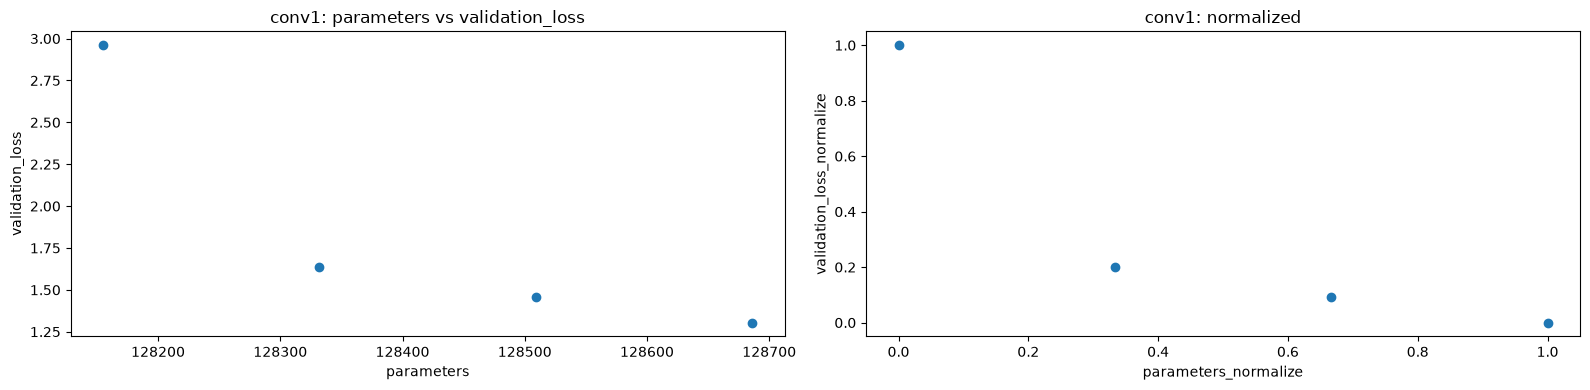

knee distance: 0.33015684641792964
knee_pos=1, neighbors iloc[0:3]
knee:


,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,baseline_time_ms,compressed_time_ms,benchmark_batch_size,benchmark_input_shape,benchmark_warmup,benchmark_repeats,agreement,logits_rmse,compressed_macs,compute_reduction,layer,rank,retained_energy,parameters_normalize,validation_loss_normalize
1,128332,0.003958,1.635332,0.511,0.2234,0.572857,0.583058,256,"(256, 3, 32, 32)",20,2000,0.5776,2.397407,362496,0.590278,conv1,6,0.600977,0.333333,0.199754


knee ±1:


,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,baseline_time_ms,compressed_time_ms,benchmark_batch_size,benchmark_input_shape,benchmark_warmup,benchmark_repeats,agreement,logits_rmse,compressed_macs,compute_reduction,layer,rank,retained_energy,parameters_normalize,validation_loss_normalize
0,128155,0.005332,2.960636,0.2538,0.4806,0.572857,0.582449,256,"(256, 3, 32, 32)",20,2000,0.2688,3.509630,181248,0.795139,conv1,3,0.365058,0.000000,1.000000
1,128332,0.003958,1.635332,0.5110,0.2234,0.572857,0.583058,256,"(256, 3, 32, 32)",20,2000,0.5776,2.397407,362496,0.590278,conv1,6,0.600977,0.333333,0.199754
2,128509,0.002585,1.457474,0.5556,0.1788,0.572857,0.582866,256,"(256, 3, 32, 32)",20,2000,0.6318,2.004653,543744,0.385417,conv1,9,0.766293,0.666667,0.092360



=== pareto / knee conv2 ===
conv2 pareto points: 6


,layer,rank,parameters,validation_loss,parameters_normalize,validation_loss_normalize
0,conv2,8,113226,1.724605,0.0,1.000000
1,conv2,16,116042,1.357592,0.2,0.610095
2,conv2,24,118858,1.089810,0.4,0.325611
3,conv2,32,121674,0.980848,0.6,0.209853
4,conv2,40,124490,0.950966,0.8,0.178107
5,conv2,48,127306,0.783316,1.0,0.000000


saved: D:\dev\nn-compression-svd-dmrg\results\30_cifar10\02_svd_global_compression_using_src_corrected\rank_sweep_results_conv2.csv
saved: D:\dev\nn-compression-svd-dmrg\results\30_cifar10\02_svd_global_compression_using_src_corrected\pareto_frontier_conv2.csv
saved: D:\dev\nn-compression-svd-dmrg\results\30_cifar10\02_svd_global_compression_using_src_corrected\parameters_vs_validation_loss_normalize_conv2.png


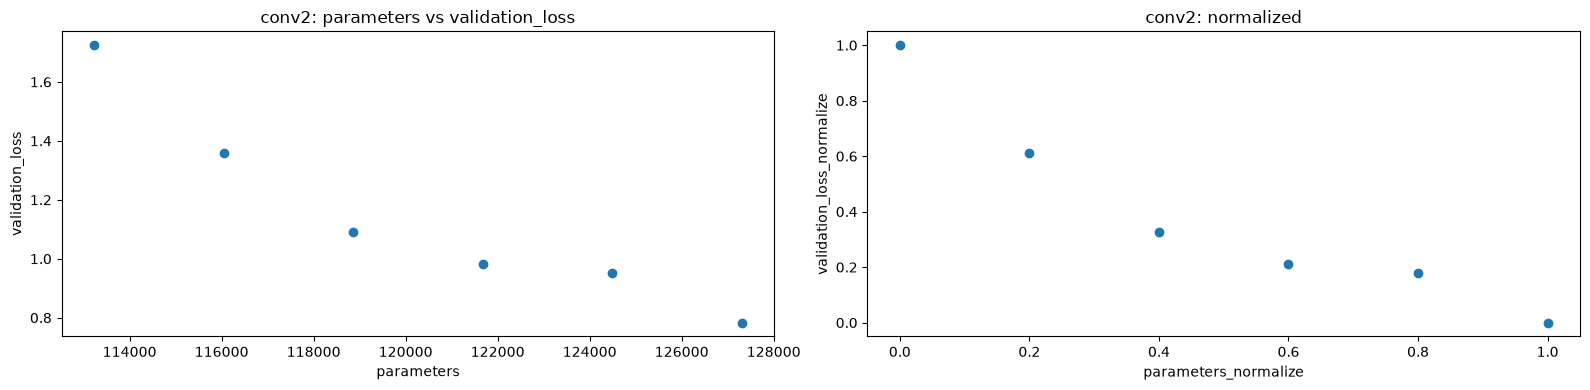

knee distance: 0.19402248848668263
knee_pos=2, neighbors iloc[1:4]
knee:


,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,baseline_time_ms,compressed_time_ms,benchmark_batch_size,benchmark_input_shape,benchmark_warmup,benchmark_repeats,agreement,logits_rmse,compressed_macs,compute_reduction,layer,rank,retained_energy,parameters_normalize,validation_loss_normalize
2,118858,0.07749,1.08981,0.6206,0.1138,0.572857,0.538705,256,"(256, 3, 32, 32)",20,2000,0.7288,1.55815,2162688,0.541667,conv2,24,0.808948,0.4,0.325611


knee ±1:


,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,baseline_time_ms,compressed_time_ms,benchmark_batch_size,benchmark_input_shape,benchmark_warmup,benchmark_repeats,agreement,logits_rmse,compressed_macs,compute_reduction,layer,rank,retained_energy,parameters_normalize,validation_loss_normalize
1,116042,0.099346,1.357592,0.5064,0.2280,0.572857,0.519711,256,"(256, 3, 32, 32)",20,2000,0.5920,2.180324,1441792,0.694444,conv2,16,0.692301,0.2,0.610095
2,118858,0.077490,1.089810,0.6206,0.1138,0.572857,0.538705,256,"(256, 3, 32, 32)",20,2000,0.7288,1.558150,2162688,0.541667,conv2,24,0.808948,0.4,0.325611
3,121674,0.055634,0.980848,0.6534,0.0810,0.572857,0.543223,256,"(256, 3, 32, 32)",20,2000,0.7844,1.044163,2883584,0.388889,conv2,32,0.881086,0.6,0.209853



=== pareto / knee conv3 ===
conv3 pareto points: 6


,layer,rank,parameters,validation_loss,parameters_normalize,validation_loss_normalize
0,conv3,16,66378,1.528999,0.0,1.000000
1,conv3,32,77642,1.033588,0.2,0.352135
2,conv3,48,88906,0.865444,0.4,0.132247
3,conv3,64,100170,0.793918,0.6,0.038711
4,conv3,80,111434,0.777464,0.8,0.017193
5,conv3,96,122698,0.764316,1.0,0.000000


saved: D:\dev\nn-compression-svd-dmrg\results\30_cifar10\02_svd_global_compression_using_src_corrected\rank_sweep_results_conv3.csv
saved: D:\dev\nn-compression-svd-dmrg\results\30_cifar10\02_svd_global_compression_using_src_corrected\pareto_frontier_conv3.csv
saved: D:\dev\nn-compression-svd-dmrg\results\30_cifar10\02_svd_global_compression_using_src_corrected\parameters_vs_validation_loss_normalize_conv3.png


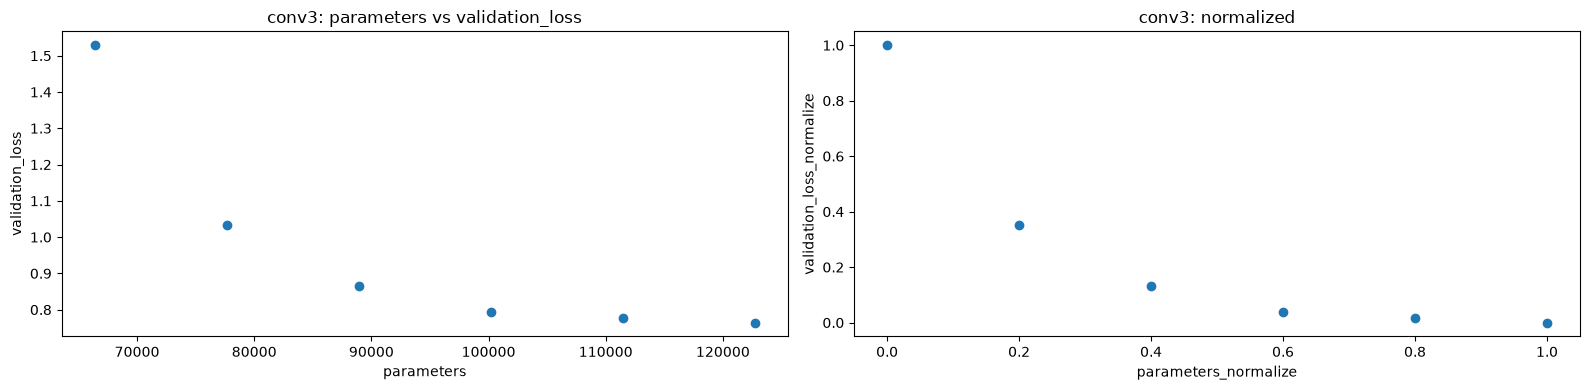

knee distance: 0.330751013485843
knee_pos=2, neighbors iloc[1:4]
knee:


,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,baseline_time_ms,compressed_time_ms,benchmark_batch_size,benchmark_input_shape,benchmark_warmup,benchmark_repeats,agreement,logits_rmse,compressed_macs,compute_reduction,layer,rank,retained_energy,parameters_normalize,validation_loss_normalize
2,88906,0.309961,0.865444,0.7064,0.028,0.572857,0.568681,256,"(256, 3, 32, 32)",20,2000,0.8838,0.767726,2162688,0.541667,conv3,48,0.880765,0.4,0.132247


knee ±1:


,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,baseline_time_ms,compressed_time_ms,benchmark_batch_size,benchmark_input_shape,benchmark_warmup,benchmark_repeats,agreement,logits_rmse,compressed_macs,compute_reduction,layer,rank,retained_energy,parameters_normalize,validation_loss_normalize
1,77642,0.397386,1.033588,0.6456,0.0888,0.572857,0.556761,256,"(256, 3, 32, 32)",20,2000,0.7722,1.314151,1441792,0.694444,conv3,32,0.788552,0.2,0.352135
2,88906,0.309961,0.865444,0.7064,0.0280,0.572857,0.568681,256,"(256, 3, 32, 32)",20,2000,0.8838,0.767726,2162688,0.541667,conv3,48,0.880765,0.4,0.132247
3,100170,0.222536,0.793918,0.7214,0.0130,0.572857,0.569436,256,"(256, 3, 32, 32)",20,2000,0.9426,0.309881,2883584,0.388889,conv3,64,0.932272,0.6,0.038711


In [17]:
# ============================================================
# 【.ipynb側】層ごとに Pareto / knee を回す
# 【.py側】frontier 抽出と膝点距離は select_pareto_knee 経由で src
# CSV は rank_sweep_results_{層名}.csv など層別に保存する
# ============================================================
layer_knee_selection: dict[str, dict] = {}
for layer_name, rank_results in layer_rank_results.items():
    print(f"\n=== pareto / knee {layer_name} ===")
    layer_knee_selection[layer_name] = select_pareto_knee(
        rank_results,
        model,
        layer_name,
        results_dir,
    )

# 例: conv1 の knee±1 は
# layer_knee_selection["conv1"]["df_pareto_best"]


## 12. 3層同時圧縮（knee ±1 の局所探索）

これは全 rank の直積を尽くす global 探索ではない。 各層の単独 Pareto knee の前後1点に制限した組み合わせ評価である。

各 Conv の `df_pareto_best` は **knee とその前後1点**（最大3点）。
3層の直積は最大 \(3^3 = 27\) 通り。

ここでは Fine-tuning せず、**3層を同時に SVD した直後**の validation を見る。
MACs はモデル全体（conv1–3 + fc1–2）を `estimate_cnn_macs` で合計する。
Linear は圧縮しない。


In [18]:
from itertools import product

from IPython.display import display

# ============================================================
# 【.ipynb側】どの層の knee±1 を直積するか、役割ラベル、保存ファイル名
# 【.py側】分解は factorize_named_layers、指標は collect_compression_metrics
# ============================================================
# 同時圧縮する Conv。Linear は今回圧縮しない
LAYER_NAMES = ("conv1", "conv2", "conv3")
# estimate_cnn_macs の合計に含める Linear。rank は渡さないので元のまま
LINEAR_LAYER_NAMES = ("fc1", "fc2")
# 進捗 print 用の短いラベル。表の列は aggressive / knee / conservative のまま
ROLE_TAG = {"aggressive": "agr", "knee": "kne", "conservative": "con"}


def knee_neighbor_roles(layer_name: str) -> dict[int, str]:
    """params 昇順の knee±1 に aggressive / knee / conservative を付ける。

    df_pareto_best は select_pareto_knee で parameters 昇順。
    左（圧縮強）→ aggressive、knee 本体、右（パラメータ多）→ conservative。
    Pareto 点が2つしかないと、knee が端になり ±1 は2点になる。
    """
    df_best = layer_knee_selection[layer_name]["df_pareto_best"]
    knee_rank = int(
        layer_knee_selection[layer_name]["df_pareto_knee"]["rank"].iloc[0]
    )
    roles: dict[int, str] = {}
    # enumerate の i=0 が「最もパラメータが少ない点」
    for i, rank in enumerate(int(r) for r in df_best["rank"].tolist()):
        if rank == knee_rank:
            roles[rank] = "knee"
        elif i == 0:
            roles[rank] = "aggressive"
        else:
            roles[rank] = "conservative"
    return roles


# 層 → {rank: 役割}。キーの順は df_pareto_best と同じ（params 昇順）
layer_rank_roles = {name: knee_neighbor_roles(name) for name in LAYER_NAMES}
layer_candidate_ranks = {
    name: list(layer_rank_roles[name]) for name in LAYER_NAMES
}
for name in LAYER_NAMES:
    print(f"{name} knee±1: {layer_rank_roles[name]}")

# 3層の直積。各層3点なら 3×3×3=27。点が足りない層があると 27 未満
rank_configs = list(
    product(*(layer_candidate_ranks[name] for name in LAYER_NAMES))
)
print(f"組み合わせ数: {len(rank_configs)}")

combination_results: list[dict] = []
for i, ranks in enumerate(rank_configs, start=1):
    conv_ranks = {
        name: int(rank) for name, rank in zip(LAYER_NAMES, ranks)
    }
    # 元の Conv2d から分解する。すでに Sequential になった層を再分解しない
    # 【.py】任意個の Conv / Linear を layer_name→rank で分解
    compressed_model = factorize_named_layers(
        model,
        conv_ranks=conv_ranks,
        linear_ranks={},
    )
    baseline_macs, compressed_macs, compute_reduction = estimate_cnn_macs(
        model,
        verbose=False,
        conv_ranks=conv_ranks,
        linear_ranks={},
        conv_output_hw=CONV_OUTPUT_HW,
        linear_layer_names=LINEAR_LAYER_NAMES,
    )
    # rank 選択用 validation。Early Stopping 用とは別 loader
    # 【.py】metrics/model_comparison.py。層名・CSV 名は含めない
    row = collect_compression_metrics(
        model,
        compressed_model,
        validation_loader_rank,
        criterion,
        device,
        baseline_acc=baseline_rank_validation_acc,
        baseline_time_s=baseline_time_s,
        warmup=BENCH_WARMUP,
        repeats=BENCH_REPEATS,
        input_batch=inference_batch,
        baseline_macs=baseline_macs,
        compressed_macs=compressed_macs,
        compute_reduction=compute_reduction,
    )
    # 今回の実験列（層名・役割・retained_energy）は Notebook で足す
    for layer_name, rank in conv_ranks.items():
        row[f"{layer_name}_rank"] = rank
        row[f"{layer_name}_role"] = layer_rank_roles[layer_name][rank]
        row[f"retained_energy_{layer_name}"] = retained_energy(
            get_named_module(model, layer_name),
            rank,
        )
    row["is_all_knee"] = all(
        layer_rank_roles[name][conv_ranks[name]] == "knee"
        for name in LAYER_NAMES
    )
    combination_results.append(row)
    print(
        f"[{i:02d}/{len(rank_configs)}] "
        f"c1={conv_ranks['conv1']}({ROLE_TAG[row['conv1_role']]}) "
        f"c2={conv_ranks['conv2']}({ROLE_TAG[row['conv2_role']]}) "
        f"c3={conv_ranks['conv3']}({ROLE_TAG[row['conv3_role']]}) | "
        f"Acc={row['validation_acc']:.4f} loss={row['validation_loss']:.4f} | "
        f"params={row['parameters']} MACs={compressed_macs}"
    )

df_combination = (
    pd.DataFrame(combination_results)
    .sort_values(["validation_loss", "parameters"])
    .reset_index(drop=True)
)
print("\nvalidation_loss 昇順:")
# 表示も CSV も PyTorch オブジェクトは落とす
display(df_combination.drop(columns=["model"]))

results_dir.mkdir(parents=True, exist_ok=True)
combination_csv_path = results_dir / "knee_combination_results.csv"
df_combination.drop(columns=["model"]).to_csv(
    combination_csv_path,
    index=False,
)
print("saved:", combination_csv_path)

# ソート後の先頭 = val loss 最小
best_row = df_combination.iloc[0]
print(
    "best (min val loss): "
    f"conv1={int(best_row['conv1_rank'])} "
    f"conv2={int(best_row['conv2_rank'])} "
    f"conv3={int(best_row['conv3_rank'])} | "
    f"loss={best_row['validation_loss']:.4f} "
    f"acc={best_row['validation_acc']:.4f}"
)

fig_comb, ax_comb = plt.subplots(figsize=(8, 5))
others = df_combination[~df_combination["is_all_knee"]]
all_knee = df_combination[df_combination["is_all_knee"]]
ax_comb.scatter(
    others["parameters"],
    others["validation_loss"],
    label="knee ±1 combinations",
)
if len(all_knee) > 0:
    ax_comb.scatter(
        all_knee["parameters"],
        all_knee["validation_loss"],
        marker="*",
        s=180,
        label="all-knee",
        zorder=3,
    )
ax_comb.scatter(
    [best_row["parameters"]],
    [best_row["validation_loss"]],
    marker="o",
    facecolors="none",
    edgecolors="black",
    s=140,
    label="best val loss",
    zorder=4,
)
ax_comb.set_xlabel("parameters")
ax_comb.set_ylabel("validation_loss")
# 横軸 params・縦軸 val loss。星 = 3層とも個別 knee、黒丸 = この27の最良
ax_comb.set_title("3-layer SVD combinations (knee ±1)")
ax_comb.legend()
ax_comb.grid(True, alpha=0.3)
plt.tight_layout()
combination_figure_path = (
    results_dir / "knee_combination_params_vs_validation_loss.png"
)
fig_comb.savefig(combination_figure_path, dpi=150, bbox_inches="tight")
print("saved:", combination_figure_path)
plt.show()


conv1 knee±1: {3: 'aggressive', 6: 'knee', 9: 'conservative'}
conv2 knee±1: {16: 'aggressive', 24: 'knee', 32: 'conservative'}
conv3 knee±1: {32: 'aggressive', 48: 'knee', 64: 'conservative'}
組み合わせ数: 27
[01/27] c1=3(agr) c2=16(agr) c3=32(agr) | Acc=0.2072 loss=2.7015 | params=64155 MACs=3100160
[02/27] c1=3(agr) c2=16(agr) c3=48(kne) | Acc=0.2046 loss=2.6578 | params=75419 MACs=3821056
[03/27] c1=3(agr) c2=16(agr) c3=64(con) | Acc=0.2052 loss=2.6753 | params=86683 MACs=4541952
[04/27] c1=3(agr) c2=24(kne) c3=32(agr) | Acc=0.2288 loss=2.6949 | params=66971 MACs=3821056
[05/27] c1=3(agr) c2=24(kne) c3=48(kne) | Acc=0.2440 loss=2.6438 | params=78235 MACs=4541952
[06/27] c1=3(agr) c2=24(kne) c3=64(con) | Acc=0.2414 loss=2.6478 | params=89499 MACs=5262848
[07/27] c1=3(agr) c2=32(con) c3=32(agr) | Acc=0.2558 loss=2.4219 | params=69787 MACs=4541952
[08/27] c1=3(agr) c2=32(con) c3=48(kne) | Acc=0.2708 loss=2.3926 | params=81051 MACs=5262848
[09/27] c1=3(agr) c2=32(con) c3=64(con) | Acc=0.2576 

KeyError: "['model'] not found in axis"

## 13. Pareto frontier（27組み合わせ）

層別 sweep ではなく、**3層同時圧縮の 27 点**に対して Pareto を取る。
やり方は Fashion-MNIST 04 と同じ。両軸とも小さいほど良い（parameters / validation_loss）。


In [ ]:
# ============================================================
# 【.ipynb側】前処理フィルタ・正規化・プロット・ファイル名
# 【.py側】Pareto frontier抽出だけ extract_pareto_frontier に任せる
# 04 と同じ手順。入力が層別 rank_results ではなく df_combination
# ============================================================
from sklearn.preprocessing import MinMaxScaler

# 【.py】metrics/model_comparison.py
baseline_params = count_parameters(model)

# 【.ipynb側】「baselineより大きいparamsを落とす」等は実験判断
df_pareto_input = df_combination[
    (df_combination["parameters"] <= baseline_params)
    & (df_combination["compute_reduction"] > 0)
].copy()

# 【.py】selection/pareto.py
# 両目的とも小さいほど良い場合の非劣後点を返す
df_pareto_view = extract_pareto_frontier(
    df_pareto_input,
    x_column="parameters",
    y_column="validation_loss",
)

# 【.ipynb側】どの列を正規化するかは実験設計
# 軸のスケールが違うと knee の「最も遠い点」が一方に偏るので 0-1 に揃える
scaler = MinMaxScaler()
df_pareto_view[
    ["parameters_normalize", "validation_loss_normalize"]
] = scaler.fit_transform(
    df_pareto_view[["parameters", "validation_loss"]]
)

# 【.ipynb側】可視化。左が生スケール、右が正規化
fig_pareto, axes_pareto = plt.subplots(1, 2, figsize=(16, 4))
axes_pareto[0].scatter(
    df_pareto_view["parameters"],
    df_pareto_view["validation_loss"],
)
axes_pareto[0].set_xlabel("parameters")
axes_pareto[0].set_ylabel("validation_loss")
axes_pareto[0].set_title("Pareto: parameters vs validation_loss")

axes_pareto[1].scatter(
    df_pareto_view["parameters_normalize"],
    df_pareto_view["validation_loss_normalize"],
)
axes_pareto[1].set_xlabel("parameters_normalize")
axes_pareto[1].set_ylabel("validation_loss_normalize")
axes_pareto[1].set_title("Pareto: normalized")
plt.tight_layout()

print("pareto points:", len(df_pareto_view))
display(
    df_pareto_view[
        [
            "conv1_rank",
            "conv2_rank",
            "conv3_rank",
            "conv1_role",
            "conv2_role",
            "conv3_role",
            "parameters",
            "validation_loss",
            "parameters_normalize",
            "validation_loss_normalize",
        ]
    ]
)

# 【.py】results_dir は get_experiment_dirs（utils/paths.py）
# 【.ipynb側】ファイル名と「model列はCSVに書かない」は実験判断
# 層別 CSV と混ぜないよう combination 用の名前にする
results_dir.mkdir(parents=True, exist_ok=True)
pareto_path = results_dir / "pareto_frontier_combination.csv"
pareto_figure_path = (
    results_dir / "parameters_vs_validation_loss_normalize_combination.png"
)

df_pareto_view.drop(columns=["model"], errors="ignore").to_csv(
    pareto_path,
    index=False,
)
fig_pareto.savefig(pareto_figure_path, dpi=150, bbox_inches="tight")

print("saved:", pareto_path)
print("saved:", pareto_figure_path)
plt.show()


## 14. knee ±1（27組み合わせの Pareto）

正規化 Pareto の端点を結ぶ直線から最も遠い点を knee とし、その前後1点も次の候補にする。
Fashion-MNIST 04 と同じ。


In [ ]:
# ============================================================
# 【.py】get_first_point / line_equation / find_knee_point
# 元03の GetPoint / GetlinearEquation / GetKneePoint_loop を
# Python標準の snake_case 名へ整理して移植
# 【.ipynb側】knee±1を候補にする、という実験判断はここに残す
# ============================================================

# 【.py】selection/knee.py
# get_first_point: 指定列でソートした先頭点の座標を返す
p0 = get_first_point(
    df_pareto_view,
    "parameters_normalize",
    "parameters_normalize",
    "validation_loss_normalize",
)
p1 = get_first_point(
    df_pareto_view,
    "validation_loss_normalize",
    "parameters_normalize",
    "validation_loss_normalize",
)

# 端点を結ぶ直線から最も遠い点が knee
knee_point, knee_distance = find_knee_point(
    df_pareto_view,
    *line_equation(p0, p1),
    "parameters_normalize",
    "validation_loss_normalize",
)

# 【.ipynb側】kneeの前後1点もFine-tuning候補にする
df_pareto_view = df_pareto_view.sort_values("parameters").reset_index(drop=True)
knee_mask = (
    (df_pareto_view["parameters_normalize"] == knee_point[0])
    & (df_pareto_view["validation_loss_normalize"] == knee_point[1])
)
knee_pos = int(df_pareto_view.index[knee_mask][0])
left = max(knee_pos - 1, 0)
right = min(knee_pos + 1, len(df_pareto_view) - 1)

df_pareto_knee = df_pareto_view.iloc[[knee_pos]].copy()
df_pareto_best = df_pareto_view.iloc[left : right + 1].copy()

print("knee distance:", knee_distance)
print(f"knee_pos={knee_pos}, neighbors iloc[{left}:{right + 1}]")
print("knee:")
display(df_pareto_knee.drop(columns=["model"], errors="ignore"))
print("knee ±1:")
display(df_pareto_best.drop(columns=["model"], errors="ignore"))

# 層別の selected_rank と混ぜない
neighbors_path = results_dir / "selected_rank_neighbors_combination.csv"
selected_path = results_dir / "selected_rank_combination.csv"
df_pareto_knee.drop(columns=["model"], errors="ignore").to_csv(
    selected_path,
    index=False,
)
df_pareto_best.drop(columns=["model"], errors="ignore").to_csv(
    neighbors_path,
    index=False,
)
print("saved:", selected_path)
print("saved:", neighbors_path)


## 15. Fine-tuning（knee ±1）

SVD 圧縮した候補ごとに optimizer と seed を作り直し、Early Stopping で Fine-tuning する。構造が変わっているので optimizer は使い回さない。
各候補は同じ `SEED` と DataLoader shuffle 状態から Fine-tuning する。 学習は `fit_with_early_stopping`（`train_eval_loader` 分離）。


In [ ]:
# ============================================================
# 【.ipynb側】どの候補をFine-tuningするか、候補ごとの seed / optimizer
# 【.py側】学習ループは fit_with_early_stopping
# 04 は conv2_rank だけ。ここでは conv1 / conv2 / conv3 の組で識別する
# ============================================================
set_seed(SEED)
fine_tuned_records = []
# Baseline は 1e-3。Fine-tuning は 04 と同じく一段下げた学習率
LEARNING_RATE = 3e-4
MAX_EPOCHS = 30


def combination_key(row) -> tuple[int, int, int]:
    """3層の rank 組。候補の突き合わせに使う。"""
    return (
        int(row["conv1_rank"]),
        int(row["conv2_rank"]),
        int(row["conv3_rank"]),
    )


# iterrowsは1行ごとに行のインデックスと Series を返す
for _, pareto_row in df_pareto_best.iterrows():
    conv1_rank, conv2_rank, conv3_rank = combination_key(pareto_row)
    conv_ranks = {
        "conv1": conv1_rank,
        "conv2": conv2_rank,
        "conv3": conv3_rank,
    }
    fine_tuned_model = factorize_named_layers(
        model,
        conv_ranks=conv_ranks,
        linear_ranks={},
    ).to(device)

    # 【.ipynb側】候補ごとに optimizer を作り直す（元03と同じ注意点）
    # SVD前は1層 Conv、SVD後は2層 Sequential なので構造が違う
    candidate_optimizer = torch.optim.Adam(
        fine_tuned_model.parameters(),
        lr=LEARNING_RATE,
    )
    # 各候補を同じ乱数条件・同じshuffle順で比較する
    set_seed(SEED)
    loader_generator.manual_seed(SEED)
    print(
        f"\n=== fine-tune "
        f"conv1={conv1_rank} conv2={conv2_rank} conv3={conv3_rank} ==="
    )

    # 【.py】training/fit.py。train 再評価は省略、毎epoch print
    fit_result = fit_with_early_stopping(
        model=fine_tuned_model,
        train_loader=train_loader,
        val_loader=validation_loader_early_stop,  # Early Stopping用（rank用ではない）
        criterion=criterion,
        optimizer=candidate_optimizer,
        device=device,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
        reevaluate_train=False,
        log_every_epoch=True,
    )

    fine_tuned_records.append(
        {
            "conv1_rank": conv1_rank,
            "conv2_rank": conv2_rank,
            "conv3_rank": conv3_rank,
            "best_epoch": fit_result["best_epoch"],
            "best_validation_loss": fit_result["best_validation_loss"],
            "history": fit_result["history"],
            "model": fit_result["model"],
        }
    )

df_fine_tuned_models = pd.DataFrame(fine_tuned_records)
display(df_fine_tuned_models.drop(columns=["history", "model"]))


## 16. Fine-tuning前後の比較

候補を Aggressive / Balanced / Conservative と名付け、validation 上の acc / loss の変化を表とグラフにする。


In [ ]:
# ============================================================
# 【.ipynb側】候補名付け・比較表・グラフ（実験固有）
# 【.py側】evaluate だけ再利用
# ============================================================
fine_tuning_records = []

for idx, pareto_row in df_pareto_best.iterrows():
    conv1_rank, conv2_rank, conv3_rank = combination_key(pareto_row)

    # 【.ipynb側】kneeより左/本体/右のラベル（元03・04と同じ）
    # df_pareto_view は parameters 昇順。左が Aggressive
    if idx < knee_pos:
        candidate = "Aggressive"
    elif idx == knee_pos:
        candidate = "Balanced"
    else:
        candidate = "Conservative"

    matched = df_fine_tuned_models[
        (df_fine_tuned_models["conv1_rank"] == conv1_rank)
        & (df_fine_tuned_models["conv2_rank"] == conv2_rank)
        & (df_fine_tuned_models["conv3_rank"] == conv3_rank)
    ]
    if len(matched) != 1:
        raise ValueError(
            "Fine-tuning済みモデルが一意に見つかりません: "
            f"conv1={conv1_rank} conv2={conv2_rank} conv3={conv3_rank} "
            f"matches={len(matched)}"
        )
    print(
        f"\n=== compare "
        f"conv1={conv1_rank} conv2={conv2_rank} conv3={conv3_rank} ==="
    )
    # 【.py】evaluate。比較は Early Stopping用ではなく validation_loader_rank
    loss_after, acc_after = evaluate(
        matched.iloc[0]["model"],
        validation_loader_rank,
        criterion,
        device,
    )
    acc_before = float(pareto_row["validation_acc"])
    loss_before = float(pareto_row["validation_loss"])

    fine_tuning_records.append(
        {
            "candidate": candidate,
            "conv1_rank": conv1_rank,
            "conv2_rank": conv2_rank,
            "conv3_rank": conv3_rank,
            "acc_before": acc_before,
            "acc_after": acc_after,
            "delta_acc": acc_after - acc_before,
            "loss_before": loss_before,
            "loss_after": loss_after,
            "delta_loss": loss_after - loss_before,
        }
    )

df_fine_tuning_result = pd.DataFrame(fine_tuning_records)
display(df_fine_tuning_result)

# 【.ipynb側】可視化
fig_delta, axes_delta = plt.subplots(1, 2, figsize=(14, 4))
axes_delta[0].plot(
    df_fine_tuning_result["candidate"],
    df_fine_tuning_result["delta_acc"],
    marker="o",
)
axes_delta[0].set_title("Fine-Tuning delta_acc")
axes_delta[0].set_ylabel("delta_acc")
axes_delta[0].grid(True, alpha=0.3)
axes_delta[1].plot(
    df_fine_tuning_result["candidate"],
    df_fine_tuning_result["delta_loss"],
    marker="o",
)
axes_delta[1].set_title("Fine-Tuning delta_loss")
axes_delta[1].set_ylabel("delta_loss")
axes_delta[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig_after, axes_after = plt.subplots(1, 2, figsize=(14, 4))
axes_after[0].plot(
    df_fine_tuning_result["candidate"],
    df_fine_tuning_result["acc_after"],
    marker="o",
)
axes_after[0].set_title("Fine-Tuning acc_after")
axes_after[0].set_ylabel("acc_after")
axes_after[0].grid(True, alpha=0.3)
axes_after[1].plot(
    df_fine_tuning_result["candidate"],
    df_fine_tuning_result["loss_after"],
    marker="o",
)
axes_after[1].set_title("Fine-Tuning loss_after")
axes_after[1].set_ylabel("loss_after")
axes_after[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 17. 最終モデル選択と Test 評価

Fine-tuning 後の Pareto から最終1モデルを選び、ここで初めて test を Baseline と比較する。


In [ ]:
# ============================================================
# 【.ipynb側】比較表の組み立て・最終選択ルール
# 【.py側】extract_pareto_frontier / evaluate / count_parameters を再利用
# ============================================================
df_candidate_params = df_pareto_best[
    [
        "conv1_rank",
        "conv2_rank",
        "conv3_rank",
        "parameters",
        "parameters_reduction",
    ]
].copy()
df_after_comparison = df_fine_tuning_result.merge(
    df_candidate_params,
    on=["conv1_rank", "conv2_rank", "conv3_rank"],
    how="left",
    validate="one_to_one",
)

comparison_records = [
    {
        "model": "Baseline",
        "conv1_rank": "-",
        "conv2_rank": "-",
        "conv3_rank": "-",
        "validation_acc": baseline_rank_validation_acc,
        "validation_loss": baseline_rank_validation_loss,
        "parameters": baseline_params,
        "parameters_reduction": 0.0,
    }
]
for _, row in df_after_comparison.iterrows():
    comparison_records.append(
        {
            "model": f"{row['candidate']} after FT",
            "conv1_rank": int(row["conv1_rank"]),
            "conv2_rank": int(row["conv2_rank"]),
            "conv3_rank": int(row["conv3_rank"]),
            "validation_acc": row["acc_after"],
            "validation_loss": row["loss_after"],
            "parameters": int(row["parameters"]),
            "parameters_reduction": row["parameters_reduction"],
        }
    )

df_model_comparison = pd.DataFrame(comparison_records)
display(df_model_comparison)

# Baselineは圧縮モデルの選択対象から除外
df_final_candidates = df_model_comparison[
    df_model_comparison["model"] != "Baseline"
].copy()

# 【.py】selection/pareto.py を再度利用
df_final_pareto = extract_pareto_frontier(
    df_final_candidates,
    x_column="parameters",
    y_column="validation_loss",
)

# 【.ipynb側】最終1モデルの優先順位（元03・04と同じ）
df_final_pareto = df_final_pareto.sort_values(
    by=["validation_loss", "parameters", "validation_acc"],
    ascending=[True, True, False],
).reset_index(drop=True)

final_model_result = df_final_pareto.iloc[0]
final_conv1_rank = int(final_model_result["conv1_rank"])
final_conv2_rank = int(final_model_result["conv2_rank"])
final_conv3_rank = int(final_model_result["conv3_rank"])
final_model = df_fine_tuned_models.loc[
    (df_fine_tuned_models["conv1_rank"] == final_conv1_rank)
    & (df_fine_tuned_models["conv2_rank"] == final_conv2_rank)
    & (df_fine_tuned_models["conv3_rank"] == final_conv3_rank),
    "model",
].iloc[0]

print("Selected final model:")
display(df_final_pareto.iloc[[0]])
print(
    "Final model: "
    f"conv1={final_conv1_rank} "
    f"conv2={final_conv2_rank} "
    f"conv3={final_conv3_rank}"
)

# 最終選択後にTestを評価
final_test_loss, final_test_acc = evaluate(
    final_model,
    test_loader,
    criterion,
    device,
)
# 圧縮前の baseline 重みで test を測る。今の model は SVD 済みなので戻す
baseline_model_for_test = make_experiment_cnn().to(device)
baseline_model_for_test.load_state_dict(baseline_state)
baseline_test_loss, baseline_test_acc = evaluate(
    baseline_model_for_test,
    test_loader,
    criterion,
    device,
)

df_test_comparison = pd.DataFrame(
    [
        {
            "model": "Baseline",
            "conv1_rank": "-",
            "conv2_rank": "-",
            "conv3_rank": "-",
            "parameters": baseline_params,
            "test_loss": baseline_test_loss,
            "test_acc": baseline_test_acc,
            "delta_test_acc": 0.0,
            "delta_test_loss": 0.0,
        },
        {
            "model": "Final (compressed + FT)",
            "conv1_rank": final_conv1_rank,
            "conv2_rank": final_conv2_rank,
            "conv3_rank": final_conv3_rank,
            "parameters": count_parameters(final_model),
            "test_loss": final_test_loss,
            "test_acc": final_test_acc,
            "delta_test_acc": final_test_acc - baseline_test_acc,
            "delta_test_loss": final_test_loss - baseline_test_loss,
        },
    ]
)
display(df_test_comparison)


## 18. 結果の保存

Fine-tuning 結果、Test 比較、最終モデルの重みを保存する。CSV の `model` 列が PyTorch オブジェクトのときは落とす。


In [ ]:
# ============================================================
# 【.ipynb側】何をどのファイル名で残すか（実験固有）
# 【.py側】results_dir / models_dir は get_experiment_dirs が用意済み
# ------------------------------------------------------------
# PyTorch の model オブジェクトは CSV に書かない。
# model_comparison / test_comparison の model 列は名前の文字列なので残す。
# ============================================================
results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)


def _drop_model_col(df):
    """CSV 向けに model 列を除いたコピーを返す"""
    return df.drop(columns=["model"], errors="ignore")


fine_tuning_csv = results_dir / "fine_tuning_result.csv"
test_comparison_csv = results_dir / "test_comparison.csv"
model_comparison_csv = results_dir / "model_comparison.csv"
selected_final_csv = results_dir / "selected_final_model.csv"
delta_figure_path = results_dir / "fine_tuning_delta.png"
after_figure_path = results_dir / "fine_tuning_after.png"

df_fine_tuning_result.to_csv(fine_tuning_csv, index=False)
df_test_comparison.to_csv(test_comparison_csv, index=False)
df_model_comparison.to_csv(model_comparison_csv, index=False)
pd.DataFrame([final_model_result]).to_csv(selected_final_csv, index=False)
fig_delta.savefig(delta_figure_path, dpi=150, bbox_inches="tight")
fig_after.savefig(after_figure_path, dpi=150, bbox_inches="tight")

saved_model_paths = []
for _, row in df_fine_tuned_models.iterrows():
    r1 = int(row["conv1_rank"])
    r2 = int(row["conv2_rank"])
    r3 = int(row["conv3_rank"])
    matched = df_fine_tuning_result[
        (df_fine_tuning_result["conv1_rank"] == r1)
        & (df_fine_tuning_result["conv2_rank"] == r2)
        & (df_fine_tuning_result["conv3_rank"] == r3)
    ]
    tag = str(matched.iloc[0]["candidate"]).lower()
    model_path = (
        models_dir
        / f"conv1-{r1}_conv2-{r2}_conv3-{r3}_{tag}_finetuned.pt"
    )
    torch.save(row["model"].state_dict(), model_path)
    saved_model_paths.append(model_path)

final_model_path = (
    models_dir
    / (
        f"conv1-{final_conv1_rank}_"
        f"conv2-{final_conv2_rank}_"
        f"conv3-{final_conv3_rank}_final.pt"
    )
)
torch.save(final_model.state_dict(), final_model_path)

for path in [
    fine_tuning_csv,
    test_comparison_csv,
    model_comparison_csv,
    selected_final_csv,
    delta_figure_path,
    after_figure_path,
    *saved_model_paths,
    final_model_path,
]:
    print("saved:", path)
